## 사용된 라이브러리
- CV2 = 핵심라이브러리 이미지의 읽기,자르기,합성,필터등 대부분을 여기서 처리해줍니다
- numpy = 수치계산 라이브러리 이미지도 숫자배열이기 때문에 numpy가 없으면 이미지 처리가 안된다고 합니다.
- torch = 이미 학습된 모델을 불러와서 이미지에서 사람/고양이 같은 객체를 자동으로 분리할때 사용
- torchvision = 이미지 전처리도구 딥러닝 모델은 아무 이미지나 못먹어서 정해진형태로 변환을 해줘야한다고 합니다.
- segmentation = 이미지에서 픽셀단위로 객체로 분류해줍니다
- matplotlib.pyplot = 우리가 쓰는 주피터에서 그림을 보여줄때 사용하는 라이브러리(사진의 출력을담당)

## 사용된 모델
- deeplabV3 + RESNET 1.1 사용이유 AI가 추천해줘서 사용해봤는데 성능이 나쁘지않아서 써봤습니다.
- 나머지 설명은 이제 각 주석에 달아놓겠습니다.

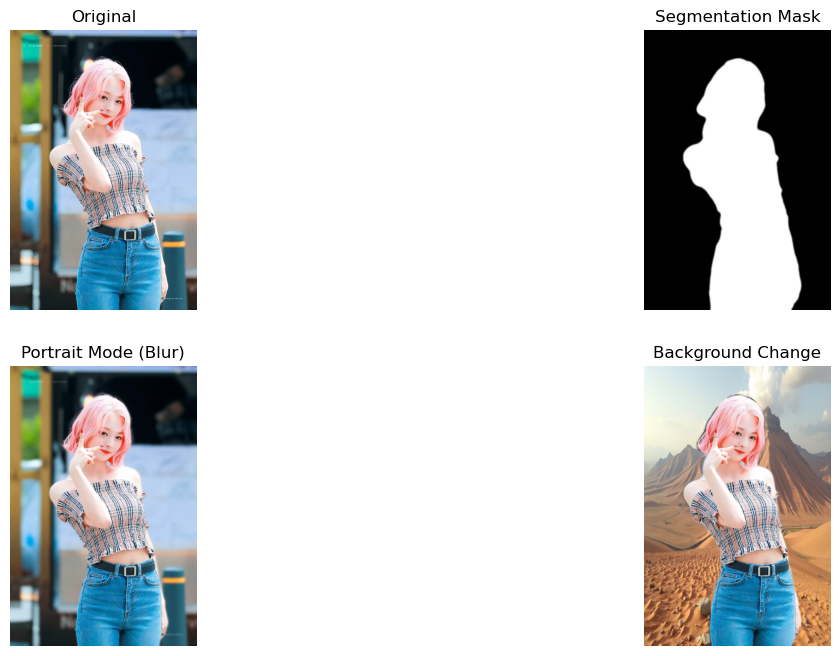

완료: portrait.png, composite.png 저장됨


In [4]:
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 경로를 설정하여 
NAKYUNG_path = "/home/jovyan/work/CV02/NAKYUNG.jpg"
sand_path = "/home/jovyan/work/CV02/sand.jpg"

# 이미지 불러오기
img = Image.open(NAKYUNG_path).convert("RGB")
sand = Image.open(sand_path).convert("RGB")

# 전처리
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)

# 모델 로드
model = deeplabv3_resnet101(pretrained=True)
model.eval()

# 추론
with torch.no_grad():
    output = model(input_tensor)['out'][0]

# 예측 결과
output_predictions = output.argmax(0).byte().cpu().numpy()

# 사람 클래스 = 15
mask = (output_predictions == 15).astype(np.uint8)

# 마스크에서 가장 큰 영역만 남기기
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)

# 오른쪽 위 쉼표 제거코드
h, w = mask.shape
mask[:int(h*0.35), int(w*0.75):] = 0

# 마스크 다듬기
kernel = np.ones((3, 3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 경계 부드럽게
mask = cv2.GaussianBlur(mask.astype(np.float32), (5, 5), 0)
mask = np.clip(mask, 0, 1)

# 가장 큰 객체 찾기 (0번은 배경이라 제외)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

# 새로운 마스크 생성
mask_clean = np.where(labels == largest_label, 1, 0).astype(np.uint8)

# 마스크 부드럽게
mask = cv2.GaussianBlur(mask.astype(float), (11,11), 0)
mask = np.clip(mask, 0, 1)

# numpy 변환
img_np = np.array(img)
sand_np = np.array(sand)

# 배경 크기 맞추기
sand_np = cv2.resize(sand_np, (img_np.shape[1], img_np.shape[0]))

# 3채널 마스크
mask_3ch = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

# 1. 인물모드 (배경 blur)
blur = cv2.GaussianBlur(img_np, (21,21), 0)
portrait = img_np * mask_3ch + blur * (1 - mask_3ch)

#  2. 배경 교체 (크로마키)
composite = img_np * mask_3ch + sand_np * (1 - mask_3ch)

#  출력 (각각의 버전을 출력)
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Segmentation Mask")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(portrait.astype(np.uint8))
plt.title("Portrait Mode (Blur)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(composite.astype(np.uint8))
plt.title("Background Change")
plt.axis("off")

plt.show()

# 저장
cv2.imwrite("/home/jovyan/work/CV02/portrait.png", cv2.cvtColor(portrait.astype(np.uint8), cv2.COLOR_RGB2BGR))
cv2.imwrite("/home/jovyan/work/CV02/composite.png", cv2.cvtColor(composite.astype(np.uint8), cv2.COLOR_RGB2BGR))

print("완료: portrait.png, composite.png 저장됨")

## 사진의 문제점
- 사진을 바라보는 오른쪽 팔이 지금 여기서 볼때는 상관이없는데 좀 당겼을때 블러처리가 됨 (이부분은 해결이안되었습니다)
- 머리카락과 목사이의 빈공간이 한사람의 객체로 판정이되어서 배경이 바뀌지않음 (이부분도 해결은안되었습니다)
- segmentation 결과에서 일부 배경 영역이 사람으로 오검출되는 문제가 발생하였는데. 이를 해결하기 위해 connected component 분석을 활용하여 주요 객체만 남기고 작은 영역을 제거하였으며, 추가적으로 특정 위치에서 발생하는 노이즈는 위치 기반 필터링을 통해 처리하였습니다. 수정전 사진과 수정후 사진을 깃허브에 남겼습니다.